<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/400_DLFoundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from numpy import ndarray
%matplotlib inline

from typing import Callable
from typing import Dict

In [3]:
print("Python list operations:")
a = [1,2,3]
b = [4,5,6]
print("a+b:", a + b)
try:
    print(a * b)
except TypeError:
    print("a*b has no meaning for Python lists")
print()
print("Numpy array operations:")
a = np.array([1,2,3])
b = np.array([4,5,6])
print("a+b:", a + b)
print("a*b:", a * b)

Python list operations:
a+b: [1, 2, 3, 4, 5, 6]
a*b has no meaning for Python lists

Numpy array operations:
a+b: [5 7 9]
a*b: [ 4 10 18]


In [4]:
a = np.array([[1,2,3],
              [4,5,6]])
print(a)
b = np.array([10,20,30])
print("a + b:\n", a + b)

[[1 2 3]
 [4 5 6]]
a + b:
 [[11 22 33]
 [14 25 36]]


In [5]:
print('a:')
print(a)
print('a.sum(axis=0):', a.sum(axis=0))
print('a.sum(axis=1):', a.sum(axis=1))

a:
[[1 2 3]
 [4 5 6]]
a.sum(axis=0): [5 7 9]
a.sum(axis=1): [ 6 15]


In [6]:
def square(x: ndarray) -> ndarray:
    '''
    Square each element in the input ndarray.
    '''
    return np.power(x, 2)

def leaky_relu(x: ndarray) -> ndarray:
    '''
    Apply "Leaky ReLU" function to each element in ndarray
    '''
    return np.maximum(0.2 * x, x)

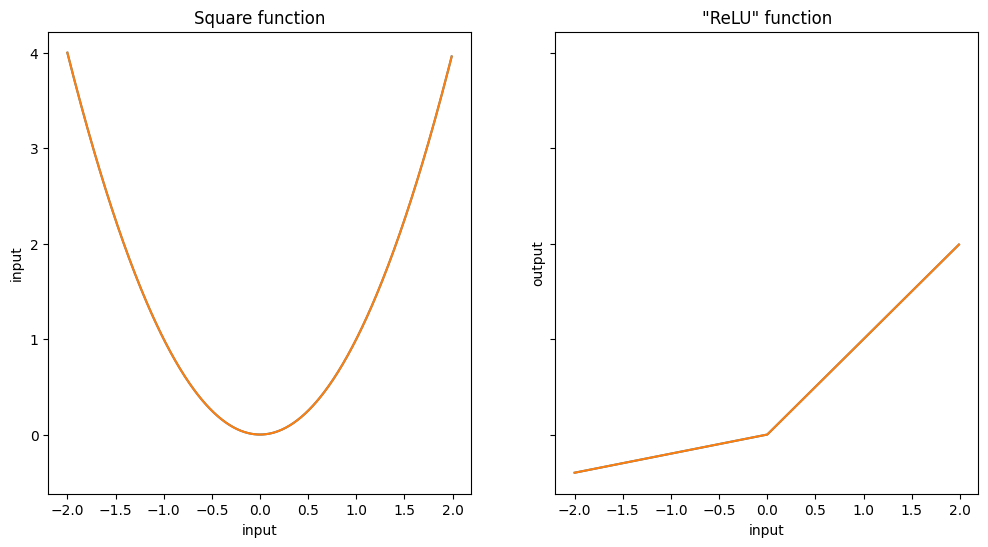

In [7]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))  # 2 Rows, 1 Col

input_range = np.arange(-2, 2, 0.01)
ax[0].plot(input_range, square(input_range))
ax[0].plot(input_range, square(input_range))
ax[0].set_title('Square function')
ax[0].set_xlabel('input')
ax[0].set_ylabel('input')

ax[1].plot(input_range, leaky_relu(input_range))
ax[1].plot(input_range, leaky_relu(input_range))
ax[1].set_title('"ReLU" function')
ax[1].set_xlabel('input')
ax[1].set_ylabel('output');

In [8]:
from typing import Callable

def deriv(func: Callable[[ndarray], ndarray],
          input_: ndarray,
          diff: float = 0.001) -> ndarray:
    '''
    Evaluates the derivative of a function "func" at every element in the "input_" array.
    '''
    return (func(input_ + diff) - func(input_ - diff)) / (2 * diff)

In [9]:
from typing import List

# A Function takes in an ndarray as an argument and produces an ndarray
Array_Function = Callable[[ndarray], ndarray]

# A Chain is a list of functions
Chain = List[Array_Function]

In [10]:
def chain_length_2(chain: Chain,
                   x: ndarray) -> ndarray:
    '''
    Evaluates two functions in a row, in a "Chain".
    '''
    assert len(chain) == 2, \
    "Length of input 'chain' should be 2"

    f1 = chain[0]
    f2 = chain[1]

    return f2(f1(x))

In [11]:
def square(x: ndarray) -> ndarray:
    '''
    Square each element in the input Tensor.
    '''
    return np.power(x, 2)

def sigmoid(x: ndarray) -> ndarray:
    '''
    Apply the sigmoid function to each element in the input ndarray.
    '''
    return 1 / (1 + np.exp(-x))

In [12]:
def chain_deriv_2(chain: Chain,
                  input_range: ndarray) -> ndarray:
    '''
    Uses the chain rule to compute the derivative of two nested functions:
    (f2(f1(x))' = f2'(f1(x)) * f1'(x)
    '''

    assert len(chain) == 2, \
    "This function requires 'Chain' objects of length 2"

    assert input_range.ndim == 1, \
    "Function requires a 1 dimensional ndarray as input_range"

    f1 = chain[0]
    f2 = chain[1]

    # df1/dx
    f1_of_x = f1(input_range)

    # df1/du
    df1dx = deriv(f1, input_range)

    # df2/du(f1(x))
    df2du = deriv(f2, f1(input_range))

    # Multiplying these quantities together at each point
    return df1dx * df2du

In [13]:
def plot_chain(ax,
               chain: Chain,
               input_range: ndarray) -> None:
    '''
    Plots a chain function - a function made up of
    multiple consecutive ndarray -> ndarray mappings -
    Across the input_range

    ax: matplotlib Subplot for plotting
    '''

    assert input_range.ndim == 1, \
    "Function requires a 1 dimensional ndarray as input_range"

    output_range = chain_length_2(chain, input_range)
    ax.plot(input_range, output_range)

In [14]:
def plot_chain_deriv(ax,
                     chain: Chain,
                     input_range: ndarray) -> ndarray:
    '''
    Uses the chain rule to plot the derivative of a function consisting of two nested functions.

    ax: matplotlib Subplot for plotting
    '''
    output_range = chain_deriv_2(chain, input_range)
    ax.plot(input_range, output_range)

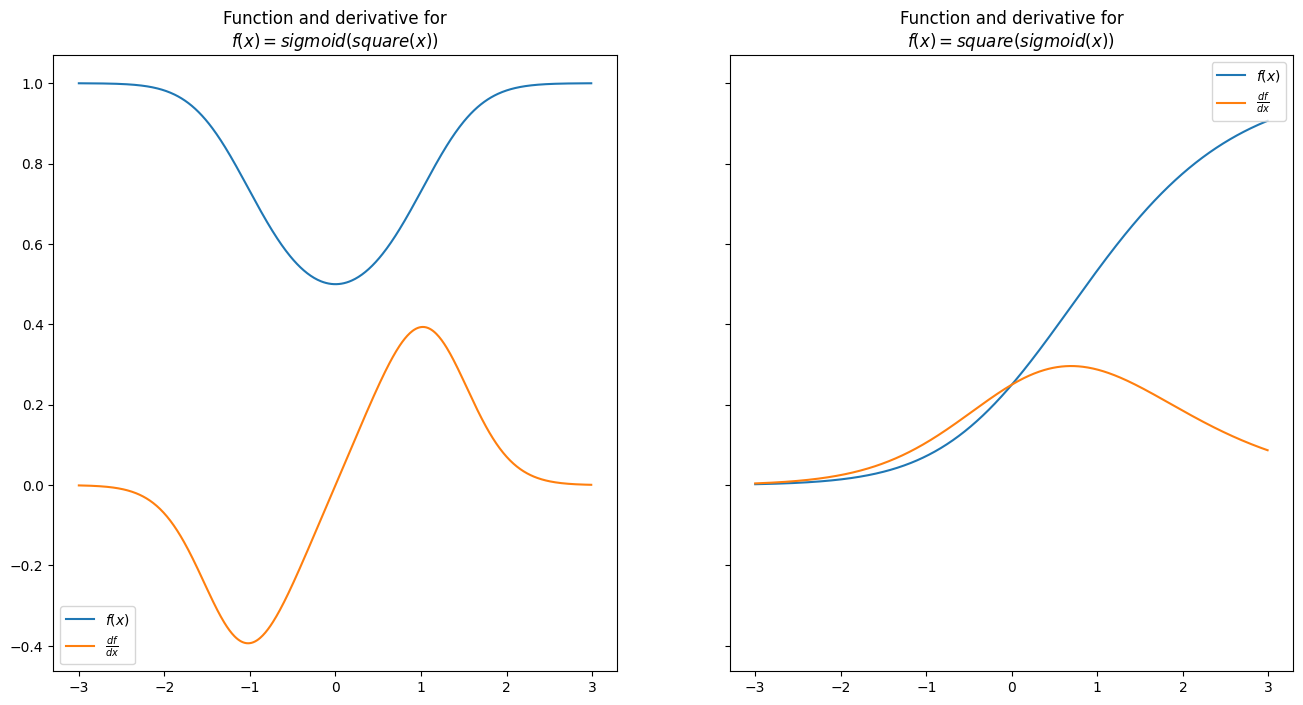

In [15]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(16, 8))  # 2 Rows, 1 Col

chain_1 = [square, sigmoid]
chain_2 = [sigmoid, square]

PLOT_RANGE = np.arange(-3, 3, 0.01)
plot_chain(ax[0], chain_1, PLOT_RANGE)
plot_chain_deriv(ax[0], chain_1, PLOT_RANGE)

ax[0].legend(["$f(x)$", "$\\frac{df}{dx}$"])
ax[0].set_title("Function and derivative for\n$f(x) = sigmoid(square(x))$")

plot_chain(ax[1], chain_2, PLOT_RANGE)
plot_chain_deriv(ax[1], chain_2, PLOT_RANGE)
ax[1].legend(["$f(x)$", "$\\frac{df}{dx}$"])
ax[1].set_title("Function and derivative for\n$f(x) = square(sigmoid(x))$");

In [16]:
import numpy as np

def min_max_normalize(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    if min_val == max_val:
        return np.zeros_like(arr, dtype=float)
    normalized_arr = (arr - min_val) / (max_val - min_val)
    return normalized_arr

def softmax(logits):
    e_x = np.exp(logits - np.max(logits))
    probabilities = e_x / e_x.sum()
    return probabilities

# Input array with three values
input_values = np.array([5.0, 7.0, 10.0])

# Normalize the values
normalized_values = min_max_normalize(input_values)

# Apply softmax to the normalized values
final_probabilities = softmax(normalized_values)

print(f"Original values: {input_values}")
print(f"Min-Max Normalized values: {normalized_values}")
print(f"Softmax output (probabilities): {final_probabilities}")
print(f"Sum of softmax probabilities: {np.sum(final_probabilities)}")

#Implement Normalize
#print(normalize(input_values))

Original values: [ 5.  7. 10.]
Min-Max Normalized values: [0.  0.4 1. ]
Softmax output (probabilities): [0.19193466 0.28633286 0.52173249]
Sum of softmax probabilities: 1.0


In [17]:
import numpy as np

def binary_cross_entropy_loss(y_true, y_pred):
    """Calculates the average binary cross-entropy loss."""
    # Add a small epsilon to avoid log(0) which is -infinity
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def mean_squared_error(y_true, y_pred):
    """Calculates the average mean squared error loss."""
    return np.mean(np.square(y_true - y_pred))

# Simulate a single data point where the model is confidently wrong
y_true = np.array([0]) # Actual label is 0 (e.g., Not Spam)
y_pred = np.array([0.99]) # Model predicts 99% probability of being 1 (Spam)

# Calculate Loss
ce_loss = binary_cross_entropy_loss(y_true, y_pred)
mse_loss = mean_squared_error(y_true, y_pred)

print(f"True label: {y_true[0]}, Predicted probability: {y_pred[0]}")
print(f"Binary Cross-Entropy Loss: {ce_loss:.4f}")
print(f"Mean Squared Error Loss: {mse_loss:.4f}")

print("-" * 30)

# Demonstrate the difference in (simplified) gradient for a single data point
# The 'gradient' for a simple linear model with sigmoid output is proportional to:
# For CE: (y_pred - y_true) / (y_pred * (1 - y_pred)) * (y_pred * (1 - y_pred)) = (y_pred - y_true)
# For MSE: (y_pred - y_true) * (y_pred * (1 - y_pred))

# Simplified gradient comparison for the confidently wrong example
# Note: These are not full backprop gradients but illustrate the core difference
ce_gradient_magnitude = np.abs(y_pred - y_true)
mse_gradient_magnitude = np.abs((y_pred - y_true) * (y_pred * (1 - y_pred)))

print(f"CE Gradient Magnitude (simplified): {ce_gradient_magnitude[0]:.4f}")
print(f"MSE Gradient Magnitude (simplified): {mse_gradient_magnitude[0]:.4f}")

# Another example where the model is less confident (error is the same for MSE in terms of absolute difference)
y_pred_unsure = np.array([0.5]) # Model predicts 50/50 chance
mse_loss_unsure = mean_squared_error(y_true, y_pred_unsure)
ce_loss_unsure = binary_cross_entropy_loss(y_true, y_pred_unsure)

print("-" * 30)
print(f"True label: {y_true[0]}, Predicted probability: {y_pred_unsure[0]}")
print(f"CE Loss (unsure): {ce_loss_unsure:.4f}")
print(f"MSE Loss (unsure): {mse_loss_unsure:.4f}")

mse_gradient_unsure = np.abs((y_pred_unsure - y_true) * (y_pred_unsure * (1 - y_pred_unsure)))
print(f"CE Gradient Magnitude (unsure): {np.abs(y_pred_unsure - y_true)[0]:.4f}")
print(f"MSE Gradient Magnitude (unsure): {mse_gradient_unsure[0]:.4f}")


True label: 0, Predicted probability: 0.99
Binary Cross-Entropy Loss: 4.6052
Mean Squared Error Loss: 0.9801
------------------------------
CE Gradient Magnitude (simplified): 0.9900
MSE Gradient Magnitude (simplified): 0.0098
------------------------------
True label: 0, Predicted probability: 0.5
CE Loss (unsure): 0.6931
MSE Loss (unsure): 0.2500
CE Gradient Magnitude (unsure): 0.5000
MSE Gradient Magnitude (unsure): 0.1250
